In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [26]:
# --- 1. Load Dataset ---
file_path = ("C:/Users/Rinu/OneDrive/Desktop/Anu's Project/infolimpioavanzadoTarget.csv")
df = pd.read_csv(file_path)
print("Dataset loaded successfully!")
print(df)


Dataset loaded successfully!
            date       open       high        low      close   adjclose  \
0     2022-01-03  17.799999  18.219000  17.500000  17.760000  17.760000   
1     2022-01-04  17.700001  18.309999  17.620001  17.660000  17.660000   
2     2022-01-05  17.580000  17.799999  16.910000  16.950001  16.950001   
3     2022-01-06  16.650000  16.879999  16.139999  16.170000  16.170000   
4     2022-01-07  16.219999  16.290001  15.630000  15.710000  15.710000   
...          ...        ...        ...        ...        ...        ...   
7776  2022-12-23  23.250000  23.540001  23.250000  23.290001  22.699928   
7777  2022-12-27  23.350000  23.610001  23.250000  23.350000  22.758406   
7778  2022-12-28  23.450001  23.570000  23.219999  23.350000  22.758406   
7779  2022-12-29  23.330000  23.740000  23.330000  23.610001  23.011820   
7780  2022-12-30  23.680000  23.760000  23.610001  23.610001  23.011820   

      volume ticker  RSIadjclose15  RSIvolume15  ...    high-15       

In [27]:
# --- 2. Data Cleaning ---
# Remove duplicate rows
df = df.drop_duplicates()
print(df)
# Drop columns with too many missing values (over 50%)
df = df.dropna(thresh=len(df) * 0.5, axis=1)
# Fill remaining missing values with mean for numeric columns
for col in df.select_dtypes(include=[np.number]).columns:
    df[col] = df[col].fillna(df[col].mean())
# Fill remaining categorical columns with mode
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].fillna(df[col].mode()[0])
# Reset index after cleaning
df = df.reset_index(drop=True)
print("Data cleaned successfully!")
print("Rows:", len(df), "| Columns:", len(df.columns), "\n")


            date       open       high        low      close   adjclose  \
0     2022-01-03  17.799999  18.219000  17.500000  17.760000  17.760000   
1     2022-01-04  17.700001  18.309999  17.620001  17.660000  17.660000   
2     2022-01-05  17.580000  17.799999  16.910000  16.950001  16.950001   
3     2022-01-06  16.650000  16.879999  16.139999  16.170000  16.170000   
4     2022-01-07  16.219999  16.290001  15.630000  15.710000  15.710000   
...          ...        ...        ...        ...        ...        ...   
7776  2022-12-23  23.250000  23.540001  23.250000  23.290001  22.699928   
7777  2022-12-27  23.350000  23.610001  23.250000  23.350000  22.758406   
7778  2022-12-28  23.450001  23.570000  23.219999  23.350000  22.758406   
7779  2022-12-29  23.330000  23.740000  23.330000  23.610001  23.011820   
7780  2022-12-30  23.680000  23.760000  23.610001  23.610001  23.011820   

      volume ticker  RSIadjclose15  RSIvolume15  ...    high-15       K-15  \
0     106600   ASLE  

c:\Users\Rinu\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\_core\_methods.py:52: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


Data cleaned successfully!
Rows: 7781 | Columns: 1285 



In [28]:
# --- 3. Handle Date column ---
if 'Date' not in df.columns:
    df['Date'] = pd.date_range(start='2020-01-01', periods=len(df), freq='D')
else:
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
print(df['Date'])


0      2020-01-01
1      2020-01-02
2      2020-01-03
3      2020-01-04
4      2020-01-05
          ...    
7776   2041-04-16
7777   2041-04-17
7778   2041-04-18
7779   2041-04-19
7780   2041-04-20
Name: Date, Length: 7781, dtype: datetime64[ns]


In [29]:
# --- 4. Handle Close column (main price column) ---
if 'Close' not in df.columns:
    num_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
    if len(num_cols) == 0:
        raise ValueError("No numeric columns found to use for price prediction.")
    close_col = num_cols[0]
    print(f"'Close' column not found. Using '{close_col}' as substitute.")
    df['Close'] = df[close_col]
print(df['Close'])


'Close' column not found. Using 'open' as substitute.
0       17.799999
1       17.700001
2       17.580000
3       16.650000
4       16.219999
          ...    
7776    23.250000
7777    23.350000
7778    23.450001
7779    23.330000
7780    23.680000
Name: Close, Length: 7781, dtype: float64


In [30]:
# --- 5. Feature Engineering ---
df['Prev_Close'] = df['Close'].shift(1)
df['Return'] = df['Close'].pct_change().fillna(0)
df = df.dropna()
print(df)


            date       open       high        low      close   adjclose  \
29    2022-02-14  15.000000  15.360000  14.590000  14.820000  14.820000   
30    2022-02-15  14.950000  15.530000  14.950000  15.500000  15.500000   
31    2022-02-16  15.360000  15.840000  15.220000  15.770000  15.770000   
32    2022-02-17  15.690000  15.690000  14.964000  15.120000  15.120000   
33    2022-02-18  15.090000  15.635000  15.055000  15.210000  15.210000   
...          ...        ...        ...        ...        ...        ...   
7776  2022-12-23  23.250000  23.540001  23.250000  23.290001  22.699928   
7777  2022-12-27  23.350000  23.610001  23.250000  23.350000  22.758406   
7778  2022-12-28  23.450001  23.570000  23.219999  23.350000  22.758406   
7779  2022-12-29  23.330000  23.740000  23.330000  23.610001  23.011820   
7780  2022-12-30  23.680000  23.760000  23.610001  23.610001  23.011820   

      volume ticker  RSIadjclose15  RSIvolume15  ...  stochastic-d-15  \
29     62900   ASLE      4

In [31]:
# --- 6. Split Data for ML ---
X = df[['Prev_Close']]
y = df['Close']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [32]:
# --- 7. Train Model ---
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully!")
print(model)



Model trained successfully!
LinearRegression()


In [33]:
# --- 8. Make Predictions ---
y_pred = model.predict(X_test)


In [34]:
# --- 9. Evaluate Model ---
accuracy = model.score(X_test, y_test)
print(f"Model Accuracy (R² Score): {accuracy:.4f}\n")

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation:")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R² Score: {r2:.4f}\n")


Model Accuracy (R² Score): 0.9990

Model Evaluation:
Mean Absolute Error (MAE): 0.8341
Mean Squared Error (MSE): 9.8198
R² Score: 0.9990



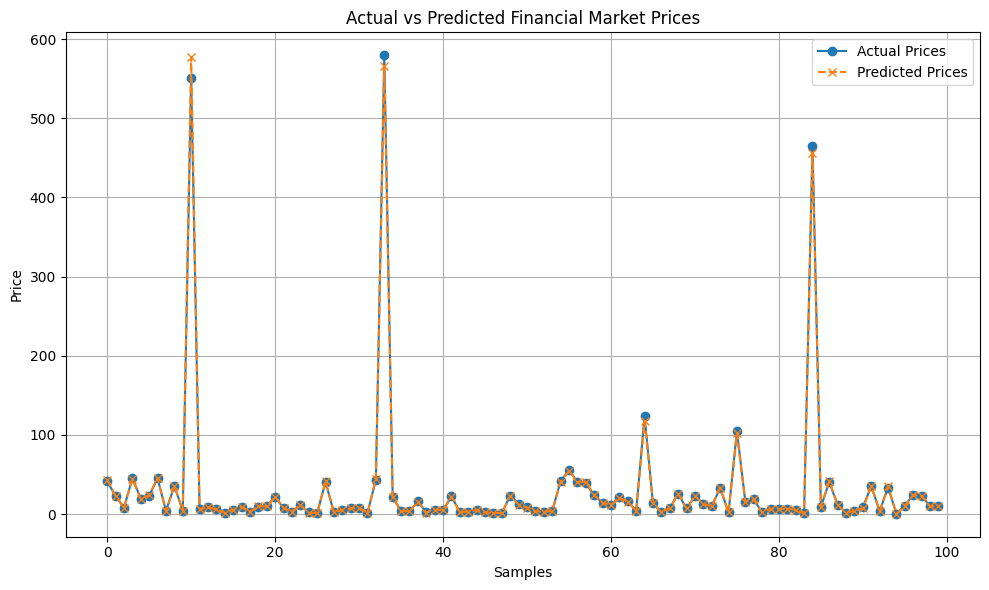

In [35]:
# --- 10. Visualization ---
plt.figure(figsize=(10,6))
plt.plot(y_test.values[:100], label='Actual Prices', marker='o')
plt.plot(y_pred[:100], label='Predicted Prices', linestyle='--', marker='x')
plt.title("Actual vs Predicted Financial Market Prices")
plt.xlabel("Samples")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


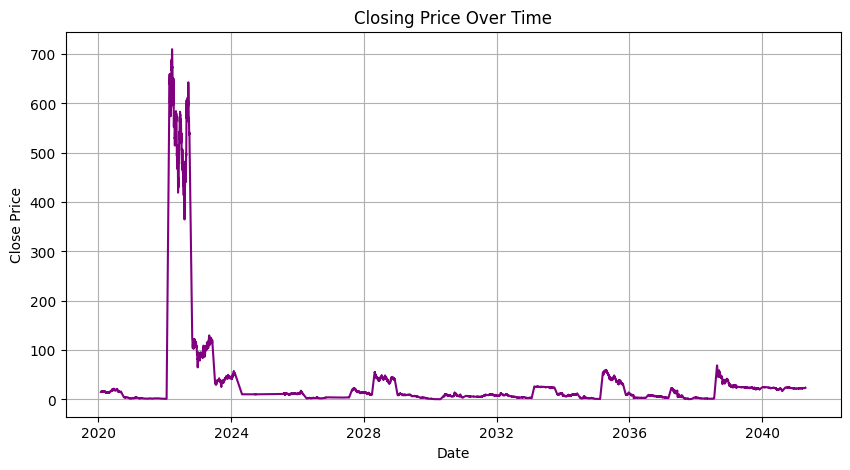

In [36]:
plt.figure(figsize=(10,5))
plt.plot(df['Date'], df['Close'], color='purple')
plt.title("Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.grid(True)
plt.show()



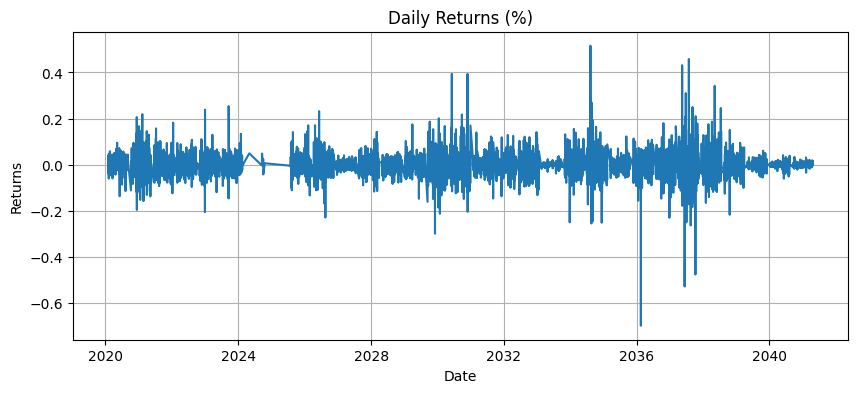

In [37]:
plt.figure(figsize=(10,4))
plt.plot(df['Date'], df['Return'])
plt.title("Daily Returns (%)")
plt.xlabel("Date")
plt.ylabel("Returns")
plt.grid(True)
plt.show()



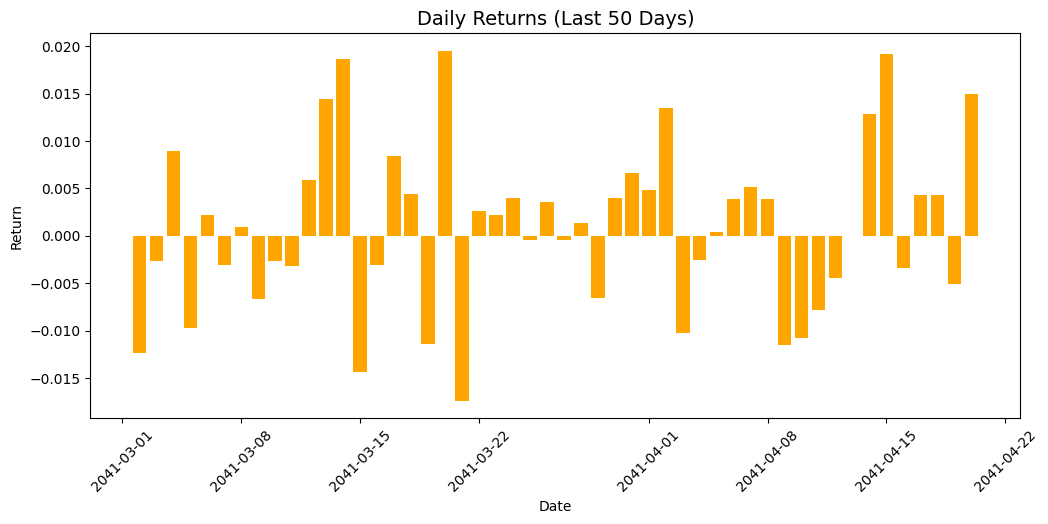

In [38]:
plt.figure(figsize=(12,5))
plt.bar(df['Date'].tail(50), df['Return'].tail(50), color='orange')
plt.title("Daily Returns (Last 50 Days)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Return")
plt.xticks(rotation=45)
plt.show()


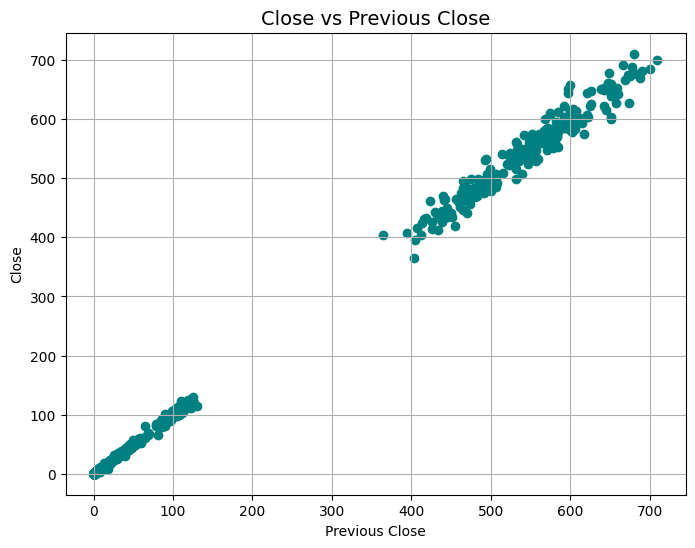

In [39]:
plt.figure(figsize=(8,6))
plt.scatter(df['Prev_Close'], df['Close'], color='teal')
plt.title("Close vs Previous Close", fontsize=14)
plt.xlabel("Previous Close")
plt.ylabel("Close")
plt.grid(True)
plt.show()



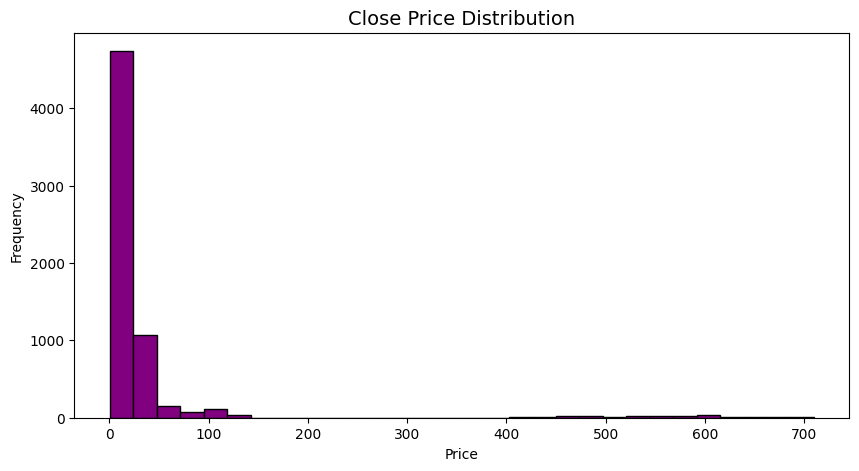

In [40]:
plt.figure(figsize=(10,5))
plt.hist(df['Close'], bins=30, color='purple', edgecolor='black')
plt.title("Close Price Distribution", fontsize=14)
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()


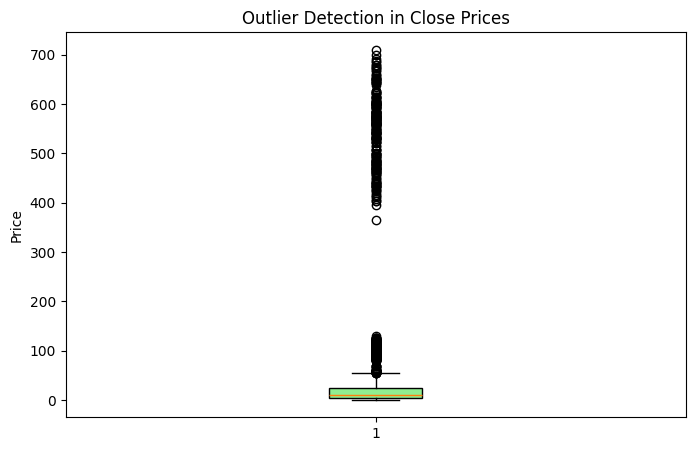

In [41]:
plt.figure(figsize=(8,5))
plt.boxplot(df['Close'], patch_artist=True,
            boxprops=dict(facecolor="lightgreen"))
plt.title("Outlier Detection in Close Prices")
plt.ylabel("Price")
plt.show()


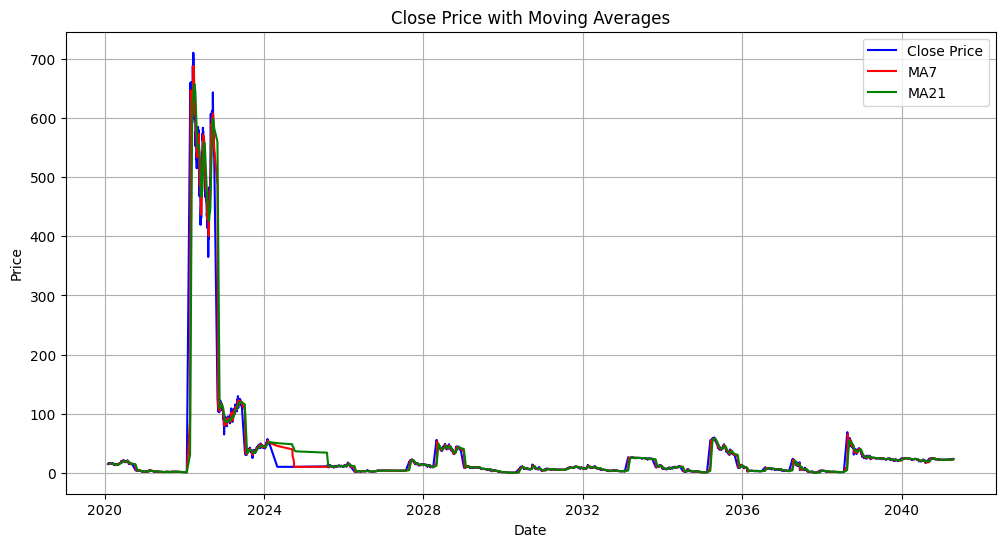

In [42]:
df['MA7'] = df['Close'].rolling(7).mean()
df['MA21'] = df['Close'].rolling(21).mean()

plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Close'], label='Close Price', color='blue')
plt.plot(df['Date'], df['MA7'], label='MA7', color='red')
plt.plot(df['Date'], df['MA21'], label='MA21', color='green')
plt.title("Close Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()


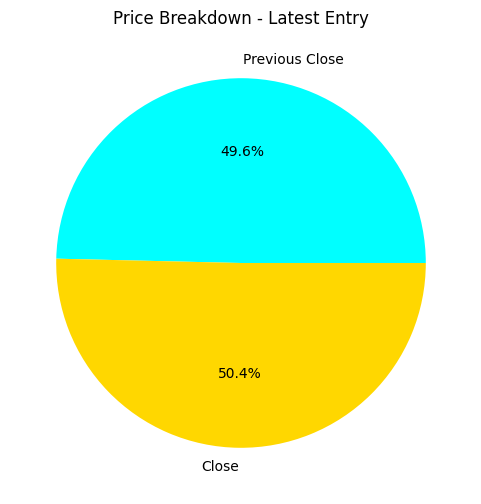

In [43]:
latest = df.tail(1)[["Prev_Close","Close"]].values.flatten()
labels = ["Previous Close", "Close"]
colors = ["cyan", "gold"]

plt.figure(figsize=(6,6))
plt.pie(latest, labels=labels, autopct="%1.1f%%", colors=colors)
plt.title("Price Breakdown - Latest Entry")
plt.show()


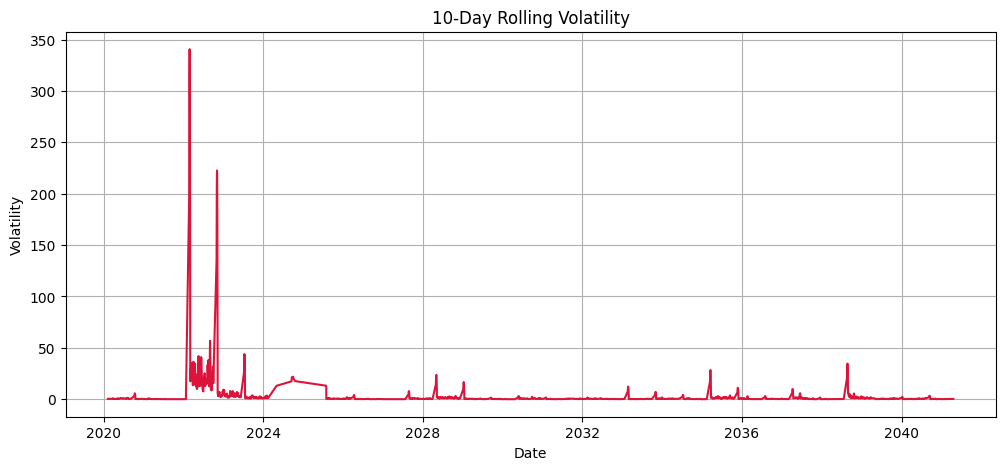

In [44]:
df['Volatility'] = df['Close'].rolling(window=10).std()
plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['Volatility'], color='crimson')
plt.title("10-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.grid(True)
plt.show()


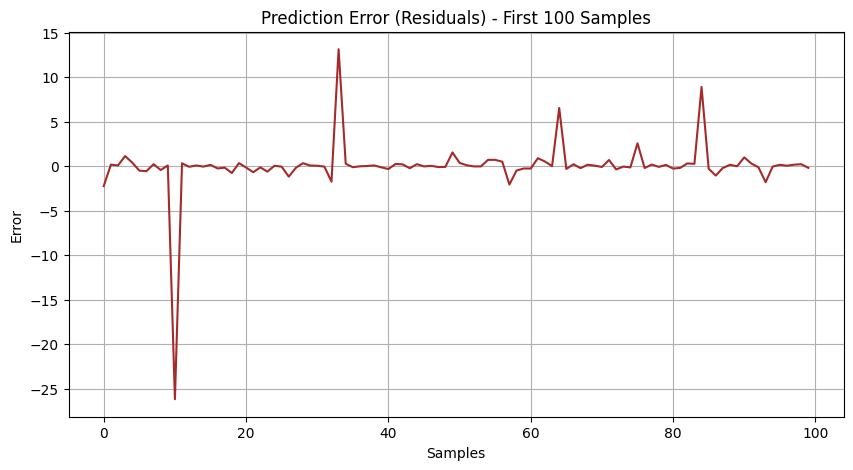

In [45]:
residuals = y_test - y_pred
plt.figure(figsize=(10,5))
plt.plot(residuals.values[:100], color='brown')
plt.title("Prediction Error (Residuals) - First 100 Samples")
plt.xlabel("Samples")
plt.ylabel("Error")
plt.grid(True)
plt.show()
